# PERSIAPAN

## Import library

In [1]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
import tensorflow as tf
import logging
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, Conv3D, MaxPooling3D,
                                     Flatten, Dense, Dropout, BatchNormalization, concatenate,
                                     GlobalAveragePooling2D)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import (MobileNetV2, EfficientNetB0, ResNet50, InceptionV3)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

2025-07-25 03:39:40.492775: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753414780.739953      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753414780.814101      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## Membuat fungsi utilitas logging

In [2]:
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s [%(levelname)s] - %(message)s',
    handlers=[
        logging.FileHandler("log_preprocessing_dataset.log", mode='w'), # Simpan log ke file
        logging.StreamHandler() # Tampilkan juga di layar
    ]
)

# Dapatkan instance logger untuk digunakan di seluruh skrip
logger = logging.getLogger(__name__)

logger.info("Sistem logging siap digunakan.")

## Membuat fungsi penyimpan hasil confusion matrix dan classification report

In [3]:
def buat_struktur_folder_run(jumlah_run: int):
    """
    Membuat struktur folder dengan format 'result/run-i'.

    Args:
        jumlah_run (int): Jumlah subfolder 'run-i' yang ingin dibuat.
    
    Returns:
        list: Sebuah list berisi path lengkap dari setiap folder yang dibuat.
    """
    # Tentukan nama folder dasar
    folder_utama = 'result'
    
    # List untuk menampung semua path yang berhasil dibuat
    path_yang_dibuat = []
    
    print(f"Mencoba membuat {jumlah_run} folder run di dalam '{folder_utama}'...")
    
    # Lakukan looping dari 1 sampai dengan jumlah_run
    for i in range(1, jumlah_run + 1):
        # Buat nama subfolder, contoh: 'run-1', 'run-2', dst.
        nama_subfolder = f'run-{i}'
        
        # Gabungkan path utama dengan subfolder menggunakan os.path.join
        path_lengkap = os.path.join(folder_utama, nama_subfolder)
        
        # Buat direktori. exist_ok=True memastikan tidak ada error jika folder sudah ada.
        os.makedirs(path_lengkap, exist_ok=True)
        
        # Tambahkan path yang baru dibuat ke dalam list
        path_yang_dibuat.append(path_lengkap)
        
    print(f"\n✅ Proses selesai. {len(path_yang_dibuat)} folder telah dibuat/diverifikasi.")
    return path_yang_dibuat


## Membuat nama lead

In [4]:
lead_names = [
    'lead_I', 'lead_II', 'lead_III',
    'lead_aVR', 'lead_aVL', 'lead_aVF',
    'lead_V1', 'lead_V2', 'lead_V3',
    'lead_V4', 'lead_V5', 'lead_V6'
]

## Membuat folder output

In [5]:
def create_output_directory():
    # --- LANGKAH 1: DEFINISIKAN SEMUA NAMA FOLDER ---

    # Definisikan nama folder paling atas (root)
    folder_utama = 'data_preprocess'
    
    # Definisikan nama-nama subfolder level 1
    subfolder_utama = ['01_gray', '02_blur', '03_thres', '04_clean', '05_lead']
    
    # Definisikan nama-nama subfolder di dalam '05_lead'
    subfolder_di_dalam_lead = ['01_long', '02_short']
    
    # Definisikan nama-nama untuk 12 lead
    nama_12_lead = list(lead_names)
    
    # --- LANGKAH 2: BUAT STRUKTUR FOLDER SECARA BERTAHAP ---
    
    logger.info(f"Membuat folder utama: '{folder_utama}'")
    os.makedirs(folder_utama, exist_ok=True) # Membuat folder utama
    
    # Membuat subfolder level 1 di dalam folder_utama
    logger.info("Membuat subfolder level 1...")
    for sub in subfolder_utama:
        path = os.path.join(folder_utama, sub)
        os.makedirs(path, exist_ok=True)
    
    # Membuat subfolder level 2 di dalam '05_lead'
    logger.info("Membuat subfolder di dalam '05_lead'...")
    path_folder_lead = os.path.join(folder_utama, '05_lead')
    for sub in subfolder_di_dalam_lead:
        path = os.path.join(path_folder_lead, sub)
        os.makedirs(path, exist_ok=True)
        
    # Membuat 12 folder lead di dalam '02_short' (level 3)
    logger.info("Membuat 12 folder lead...")
    path_folder_short = os.path.join(path_folder_lead, '02_short')
    for nama_lead in nama_12_lead:
        path = os.path.join(path_folder_short, nama_lead)
        os.makedirs(path, exist_ok=True)
    
    logger.info("\n✅ Struktur folder telah berhasil dibuat!")

In [6]:
create_output_directory()

# Langkah 1: Proses dataset

## Membuat fungsi proses satu gambar ekg

In [7]:
def preprocess_single_ecg_dual_output(image_path):
    try:
        gambar_asli = cv2.imread(image_path)
        nama_file = os.path.basename(image_path)
        if gambar_asli is None:
            print(f"  - Gagal memuat gambar: {image_path}")
            return None, None
        
        # --- Tahap 1-4: Preprocessing, Deteksi, dan Cropping (Tidak ada perubahan) ---
        gambar_gray = cv2.cvtColor(gambar_asli, cv2.COLOR_BGR2GRAY)
        gambar_blurred = cv2.GaussianBlur(gambar_gray, (5, 5), 0)
        ret, gambar_thresholded = cv2.threshold(gambar_blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
        kernel = np.ones((3,3), np.uint8)
        gambar_cleaned = cv2.morphologyEx(gambar_thresholded, cv2.MORPH_OPEN, kernel)
        
        contours, _ = cv2.findContours(gambar_cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        kontur_valid = [c for c in contours if cv2.contourArea(c) > 5000]

        if len(kontur_valid) < 2:
            print(f"  - Tidak ditemukan kontur yang cukup pada: {image_path}")
            return None, None

        kontur_valid.sort(key=lambda c: cv2.boundingRect(c)[1])
        (x_12, y_12, w_12, h_12) = cv2.boundingRect(kontur_valid[0])
        (x_long, y_long, w_long, h_long) = cv2.boundingRect(kontur_valid[-1])
        crop_12_lead_cleaned = gambar_cleaned[y_12:y_12+h_12, x_12:x_12+w_12]
        crop_long_lead_cleaned = gambar_cleaned[y_long:y_long+h_long, x_long:x_long+w_long]
        
        UKURAN_STANDAR_BLOK = (1980, 786)
        crop_12_lead_standardized = cv2.resize(crop_12_lead_cleaned, UKURAN_STANDAR_BLOK, interpolation=cv2.INTER_AREA)
        
        # --- Tahap 5: Pemisahan 12-Lead Manual ---
        koordinat_leads = [
             (6, 0, 493, 262), (502, 0, 989, 262), (993, 0, 1480, 262), (1485, 0, 1972, 262),
             (6, 262, 493, 524), (502, 262, 989, 524), (993, 262, 1480, 524), (1485, 262, 1972, 524),
             (6, 524, 493, 786), (502, 524, 989, 786), (993, 524, 1480, 786), (1485, 524, 1972, 786)
        ]
        list_hasil_manual = [crop_12_lead_standardized[y1:y2, x1:x2] for (x1, y1, x2, y2) in koordinat_leads]

        # --- Tahap 6: Resize Akhir dan Stacking ---
        UKURAN_TARGET_12_LEAD = (224, 144)
        list_12_lead_resized = [cv2.resize(p, UKURAN_TARGET_12_LEAD, interpolation=cv2.INTER_AREA) for p in list_hasil_manual]

        if len(list_12_lead_resized) != 12: 
            return None, None
            
        volume_3d_ekg = np.stack(list_12_lead_resized, axis=0)
        
        # --- Tahap 7: Proses Long-Lead ---
        UKURAN_TARGET_LONG_LEAD = (898, 141)
        long_lead_resized = cv2.resize(crop_long_lead_cleaned, UKURAN_TARGET_LONG_LEAD, interpolation=cv2.INTER_AREA)
        return volume_3d_ekg, long_lead_resized

    except Exception as e:
        print(f"  - Terjadi error saat memproses {image_path}: {e}")
        return None, None

## Membuat proses batch

In [8]:
path_dataset_utama = "/kaggle/input/dataset-final"
X_12_lead_data = []
X_long_lead_data = []
y_labels = []

if not os.path.exists(path_dataset_utama):
    print(f"Error: Direktori '{path_dataset_utama}' tidak ditemukan.")
else:
    for nama_kategori in sorted(os.listdir(path_dataset_utama)):
        path_kategori = os.path.join(path_dataset_utama, nama_kategori)
        if os.path.isdir(path_kategori):
            print(f"\nMemproses kategori: '{nama_kategori}'...")
            for nama_file in os.listdir(path_kategori):
                path_file_gambar = os.path.join(path_kategori, nama_file)
        
                # Panggil fungsi yang mengembalikan tiga nilai
                hasil_proses = preprocess_single_ecg_dual_output(path_file_gambar)
                
                # Unpacking yang aman
                if hasil_proses and all(item is not None for item in hasil_proses):
                    # Bongkar dua nilai jika pemrosesan berhasil
                    volume, long_lead = hasil_proses
                    
                    # Masukkan setiap data ke listnya masing-masing
                    X_12_lead_data.append(volume)
                    X_long_lead_data.append(long_lead)
                    y_labels.append(nama_kategori)
                    
                    # print(f"  - Berhasil memproses: {nama_file}")
    
    print("\n=====================================")
    print("SELURUH DATASET TELAH SELESAI DIPROSES.")
    print(f"Total gambar yang berhasil diproses: {len(y_labels)}")
    print("=====================================")

# --- TAHAP FINAL: KONVERSI & SIMPAN TIGA FILE .NPY TERPISAH ---
if y_labels:
    
    # Konversi dan simpan data 12-lead (volume)
    X_12_lead_final = np.array(X_12_lead_data)
    np.save('X_12_lead_processed.npy', X_12_lead_final)
    print(f"\nData 12-Lead (volume) disimpan ke 'X_12_lead_processed.npy'")
    print(f"Bentuk (shape) data: {X_12_lead_final.shape}")
    
    # Konversi dan simpan data long-lead
    X_long_lead_final = np.array(X_long_lead_data)
    np.save('X_long_lead_processed.npy', X_long_lead_final)
    print(f"\nData Long-Lead (gambar) disimpan ke 'X_long_lead_processed.npy'")
    print(f"Bentuk (shape) data: {X_long_lead_final.shape}")
    
    # Konversi dan simpan label (tidak ada perubahan)
    y_final = np.array(y_labels)
    np.save('y_labels.npy', y_final)
    print(f"\nLabel disimpan ke 'y_labels.npy'")
    print(f"Bentuk (shape) data: {y_final.shape}")


Memproses kategori: 'abnormal'...

Memproses kategori: 'history_myocardial_infaction'...

Memproses kategori: 'myocardial_infarction'...

Memproses kategori: 'normal'...

SELURUH DATASET TELAH SELESAI DIPROSES.
Total gambar yang berhasil diproses: 928

Data 12-Lead (volume) disimpan ke 'X_12_lead_processed.npy'
Bentuk (shape) data: (928, 12, 144, 224)

Data Long-Lead (gambar) disimpan ke 'X_long_lead_processed.npy'
Bentuk (shape) data: (928, 141, 898)

Label disimpan ke 'y_labels.npy'
Bentuk (shape) data: (928,)


## Load data gambar yang sudah diproses

In [9]:
def load_and_prepare_dataset(path_x12, path_xlong, path_y):
    print("Memuat 2 set data input yang sudah diproses...")
    try:
        # Hanya muat dua file X
        X_12_lead = np.load(path_x12)
        X_long_lead = np.load(path_xlong)
        y_str = np.load(path_y)
        
    except FileNotFoundError:
        print(f"Error: Salah satu atau lebih file tidak ditemukan. Periksa kembali path file.")
        # Kembalikan 5 nilai None
        return None, None, None, None, None
    else:
        print("Data berhasil dimuat.")
        print(f"Bentuk X_12_lead: {X_12_lead.shape}")
        print(f"Bentuk X_long_lead: {X_long_lead.shape}")
        print(f"Bentuk y_str: {y_str.shape}")
        
        # --- ENCODING LABEL (Tidak ada perubahan) ---
        print("\nMelakukan encoding pada label...")
        encoder = LabelEncoder()
        y_encoded = encoder.fit_transform(y_str)
        num_classes = len(encoder.classes_)
        
        print(f"Jumlah kelas: {num_classes}")
        print("Pemetaan Label:")
        for i, kelas in enumerate(encoder.classes_):
            print(f"- {kelas} -> {i}")
            
        # Kembalikan semua 2 array X dan hasil label
        return X_12_lead, X_long_lead, y_encoded, num_classes, encoder

## Membagi dataset untuk data latih, validasi, dan tes

In [10]:
# 1. Definisikan path ke file-file Anda
path_12_lead = 'X_12_lead_processed.npy'
path_long_lead = 'X_long_lead_processed.npy'
path_label = 'y_labels.npy'

# 2. Panggil fungsi untuk memuat dan mempersiapkan semua data
X_12, X_long, y, NUM_CLASSES, encoder = load_and_prepare_dataset(
    path_12_lead, 
    path_long_lead, 
    path_label
)

Memuat 2 set data input yang sudah diproses...
Data berhasil dimuat.
Bentuk X_12_lead: (928, 12, 144, 224)
Bentuk X_long_lead: (928, 141, 898)
Bentuk y_str: (928,)

Melakukan encoding pada label...
Jumlah kelas: 4
Pemetaan Label:
- abnormal -> 0
- history_myocardial_infaction -> 1
- myocardial_infarction -> 2
- normal -> 3


In [11]:
def pembagian_data(*X_arrays, y, test_size=0.20, val_size=0.20, random_state=42):
    # Dapatkan jumlah total sampel
    num_samples = len(y)
    # Buat array berisi semua indeks dari 0 sampai N-1
    indices = np.arange(num_samples)

    # Tahap 1: Pisahkan indeks menjadi train_pool dan test
    train_val_indices, test_indices = train_test_split(
        indices,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    # Ambil label untuk train_pool untuk stratifikasi selanjutnya
    y_train_val = y[train_val_indices]
    
    # Tahap 2: Pisahkan indeks train_pool menjadi train final dan validation
    train_indices, val_indices = train_test_split(
        train_val_indices,
        test_size=val_size,
        random_state=random_state,
        stratify=y_train_val
    )

    # Sekarang kita punya 3 set indeks: train_indices, val_indices, test_indices
    
    # Gunakan indeks ini untuk memotong semua array X
    X_trains = [X[train_indices] for X in X_arrays]
    X_vals = [X[val_indices] for X in X_arrays]
    X_tests = [X[test_indices] for X in X_arrays]
    
    # Gunakan indeks untuk memotong array y
    y_train = y[train_indices]
    y_val = y[val_indices]
    y_test = y[test_indices]
    
    # Kembalikan semua bagian dalam bentuk list untuk X dan array untuk y
    return X_trains, X_vals, X_tests, y_train, y_val, y_test

In [12]:
def reshape_multidata_for_2d_model(list_of_x_arrays):
    print(f"Mereshape {len(list_of_x_arrays)} set data...")
    
    reshaped_list = []
    for i, data in enumerate(list_of_x_arrays):
        # Jika data memiliki 4 dimensi (seperti volume 12-lead atau 6-lead)
        if data.ndim == 4:
            print(f"  - Mentranspose data ke-{i+1} dari {data.shape}...")
            reshaped_data = data.transpose(0, 2, 3, 1)
            reshaped_list.append(reshaped_data)
            print(f"    -> Bentuk baru: {reshaped_data.shape}")
        # Jika data memiliki 3 dimensi (seperti long-lead)
        elif data.ndim == 3:
            print(f"  - Menambah dimensi channel pada data ke-{i+1} dari {data.shape}...")
            reshaped_data = np.expand_dims(data, axis=-1)
            reshaped_list.append(reshaped_data)
            print(f"    -> Bentuk baru: {reshaped_data.shape}")
        else:
            print(f"  - Data ke-{i+1} sudah memiliki dimensi yang benar atau tidak dikenali. Dilewati.")
            reshaped_list.append(data)
            
    return reshaped_list

In [13]:
X_train_list, X_val_list, X_test_list, \
y_train, y_val, y_test = pembagian_data(
                                X_12,
                                X_long, 
                                y=y,
                                test_size=0.20,
                                val_size=0.25 # 25% dari 80% -> 20% dari total
                            )

# # --- Verifikasi Hasil Akhir ---
print("\n--- UKURAN DATASET SETELAH DIBAGI ---")
print(f"Jumlah set X untuk training: {len(X_train_list)}")
print(f"  - Bentuk X_12: {X_train_list[0].shape}")
print(f"  - Bentuk X_long_train: {X_train_list[1].shape}")
print(f"Bentuk y_train: {y_train.shape}")
print("-" * 20)
print(f"Jumlah sampel validasi: {len(y_val)}")
print(f"Jumlah sampel tes: {len(y_test)}")

# # Jangan lupa menambahkan dimensi channel untuk input CNN jika belum
# X_12_train = np.expand_dims(X_12_train, axis=-1)
# X_12_val = np.expand_dims(X_12_val, axis=-1)
# X_12_test = np.expand_dims(X_12_test, axis=-1)

# X_long_train = np.expand_dims(X_long_train, axis=-1)
# X_long_val = np.expand_dims(X_long_val, axis=-1)
# X_long_test = np.expand_dims(X_long_test, axis=-1)

# --- LANGKAH 4 (KRUSIAL): MENYIAPKAN BENTUK DATA UNTUK MODEL 2D ---
# Pastikan Anda menjalankan blok ini dengan benar!

print("\n--- Mereshape Data Training ---")
X_train_reshaped = reshape_multidata_for_2d_model(X_train_list)

print("\n--- Mereshape Data Validasi ---")
X_val_reshaped = reshape_multidata_for_2d_model(X_val_list)

print("\n--- Mereshape Data Tes ---")
X_test_reshaped = reshape_multidata_for_2d_model(X_test_list)

print("\nSemua data telah berhasil di-reshape dan siap untuk model.")


--- UKURAN DATASET SETELAH DIBAGI ---
Jumlah set X untuk training: 2
  - Bentuk X_12: (556, 12, 144, 224)
  - Bentuk X_long_train: (556, 141, 898)
Bentuk y_train: (556,)
--------------------
Jumlah sampel validasi: 186
Jumlah sampel tes: 186

--- Mereshape Data Training ---
Mereshape 2 set data...
  - Mentranspose data ke-1 dari (556, 12, 144, 224)...
    -> Bentuk baru: (556, 144, 224, 12)
  - Menambah dimensi channel pada data ke-2 dari (556, 141, 898)...
    -> Bentuk baru: (556, 141, 898, 1)

--- Mereshape Data Validasi ---
Mereshape 2 set data...
  - Mentranspose data ke-1 dari (186, 12, 144, 224)...
    -> Bentuk baru: (186, 144, 224, 12)
  - Menambah dimensi channel pada data ke-2 dari (186, 141, 898)...
    -> Bentuk baru: (186, 141, 898, 1)

--- Mereshape Data Tes ---
Mereshape 2 set data...
  - Mentranspose data ke-1 dari (186, 12, 144, 224)...
    -> Bentuk baru: (186, 144, 224, 12)
  - Menambah dimensi channel pada data ke-2 dari (186, 141, 898)...
    -> Bentuk baru: (186

# Langkah 2: Membuat model

## Membuat satu fungsi untuk menggunakan salah satu model yang sudah tersedia

In [14]:
def create_flexible_transfer_model(list_of_input_shapes, num_classes, model_name='MobileNetV2'):
    
    model_inputs = []         # Untuk menampung semua layer Input
    branch_feature_outputs = [] # Untuk menampung output fitur dari setiap cabang

    # Dictionary untuk memilih model dasar
    base_models = {
        'MobileNetV2': MobileNetV2,
        # 'EfficientNetB0': EfficientNetB0,
        'ResNet50': ResNet50,
        'InceptionV3': InceptionV3
    }
    
    # --- Loop untuk membuat setiap cabang secara dinamis ---
    for i, input_shape in enumerate(list_of_input_shapes):
        # 1. Buat layer Input untuk cabang ini
        current_input = Input(shape=input_shape, name=f'input_branch_{i+1}')
        model_inputs.append(current_input)
        
        # 2. Lapisan Adaptasi (mengubah channel input menjadi 3)
        adapter = Conv2D(3, (1, 1), padding='same', activation='relu', name=f'adapter_branch_{i+1}')(current_input)
        
        # 3. Buat instance model dasar dengan nama unik
        Base_Model_Class = base_models[model_name]
        base_model = Base_Model_Class(
            input_shape=input_shape[:2] + (3,), 
            include_top=False, 
            weights='imagenet',
            name=f'base_model_branch_{i+1}' # Nama unik untuk setiap cabang
        )
        base_model.trainable = False
        
        # 4. Proses input melalui cabang
        features = base_model(adapter, training=False)
        features = GlobalAveragePooling2D(name=f'gap_branch_{i+1}')(features)
        branch_feature_outputs.append(features)

    # --- Penggabungan (Merge) ---
    # Jika ada lebih dari satu cabang, gabungkan. Jika tidak, gunakan saja output tunggal.
    if len(branch_feature_outputs) > 1:
        gabungan = concatenate(branch_feature_outputs, name='concatenate_features')
    else:
        gabungan = branch_feature_outputs[0]
        
    # --- Kepala Klasifikasi ---
    x = Dense(256, activation='relu')(gabungan)
    x = Dropout(0.5)(x)
    output_final = Dense(num_classes, activation='softmax')(x)
    
    # --- Buat Model Final ---
    # `inputs` sekarang adalah list dari semua layer Input yang kita buat
    model = Model(inputs=model_inputs, outputs=output_final)
    
    return model

## Menyiapkan input yang akan digunakan model

In [15]:
# Dapatkan bentuk input dari data yang sudah di-reshape
list_of_shapes = [data.shape[1:] for data in X_train_reshaped]

# Langkah 3: Melatih Model

## Melatih seluruh model

### Membuat model dan debug isi model

### Melatih model

# Langkah 4: Evaluasi

## Evaluasi model dengan cara membuat confusion matrix

In [16]:
def simpan_laporan_kinerja(history, model, X_test, y_test, nama_model, folder_tujuan='hasil_evaluasi'):
    try:
        print(f"\n--- Membuat Laporan Kinerja untuk: {nama_model} ---")

        # --- LANGKAH 1: EKSTRAK METRIK DARI DATA VALIDASI ---
        val_accuracy_terbaik = np.max(history.history['val_accuracy'])
        val_loss_terbaik = np.min(history.history['val_loss'])
        epoch_terbaik = np.argmin(history.history['val_loss']) + 1

        # --- LANGKAH 2: EVALUASI PADA DATA TES ---
        loss_tes, akurasi_tes = model.evaluate(X_test, y_test, verbose=0)

        # --- LANGKAH 3: BUAT STRING LAPORAN LENGKAP ---
        laporan_teks = (
            f"Laporan Kinerja Model: {nama_model}\n"
            f"================================================\n\n"
            f"METRIK PADA DATA VALIDASI (selama pelatihan):\n"
            f"--------------------------------------------\n"
            f"Akurasi Validasi Tertinggi: {val_accuracy_terbaik:.4f}\n"
            f"Loss Validasi Terendah    : {val_loss_terbaik:.4f}\n"
            f"Dicapai pada Epoch          : {epoch_terbaik}\n\n"
            f"METRIK PADA DATA TES (evaluasi akhir):\n"
            f"----------------------------------------\n"
            f"Akurasi Tes Final: {akurasi_tes:.4f}\n"
            f"Loss Tes Final   : {loss_tes:.4f}\n"
        )
        
        # Cetak laporan ke konsol
        print(laporan_teks)
        
        # Buat nama file yang unik
        nama_file_output = f'kinerja_{nama_model.lower()}.txt'
        path_lengkap = os.path.join(folder_tujuan, nama_file_output)
        
        # Tulis ke file
        with open(path_lengkap, 'w') as f:
            f.write(laporan_teks)
            
        print(f"\n✅ Laporan kinerja telah disimpan di: '{path_lengkap}'")

    except Exception as e:
        print(f"❌ Terjadi error saat membuat laporan kinerja: {e}")

In [17]:
def lakukan_prediksi(model, list_data_tes, label_tes):
    print("Melakukan prediksi pada data tes...")
    
    # PERUBAHAN: model.predict() sekarang menerima list dari array data tes
    y_pred_probs = model.predict(list_data_tes)
    
    # Mengambil kelas dengan probabilitas tertinggi
    y_pred_classes = np.argmax(y_pred_probs, axis=1)
    
    # Menghitung confusion matrix
    # y_test harus dalam format integer (bukan one-hot)
    cm = confusion_matrix(label_tes, y_pred_classes)

    print("Prediksi dan pembuatan confusion matrix selesai.")
    return cm, y_pred_classes

In [18]:
def menampilkan_dan_menyimpan_confusion_matrix(cm, path, nama_model='MobileNetV2'):
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=encoder.classes_, yticklabels=encoder.classes_)
    plt.title(f'Confusion Matrix - Preproses Terbaik - {nama_model}')
    plt.ylabel('Kelas Asli (True Label)')
    plt.xlabel('Kelas Prediksi (Predicted Label)')
    
    nama_file_output = os.path.join(path, f'confusion_matrix_{nama_model.lower()}_terbaik.jpg')
    plt.savefig(nama_file_output, dpi=300, bbox_inches='tight')
    print(f"\nPlot confusion matrix telah disimpan sebagai: '{nama_file_output}'")
    
    plt.show()

## Evaluasi model dengan cara membuat classification report

In [19]:
def ubah_format_onehot(label):
    if label.ndim > 1:
        y_test_classes = np.argmax(label, axis=1)
    else:
        y_test_classes = y_test

    return y_test_classes

In [20]:
def generate_and_save_classification_report(y_true, y_pred, encoder, report_filename):
    try:
        # --- Persiapan Label ---
        # Jika y_true dalam format one-hot, ubah kembali ke format integer
        if y_true.ndim > 1 and y_true.shape[1] > 1:
            y_true_classes = np.argmax(y_true, axis=1)
        else:
            y_true_classes = y_true # Jika sudah integer

        # Dapatkan nama kelas dari encoder untuk pelabelan laporan
        target_names = encoder.classes_

        # --- Buat dan Cetak Laporan ---
        print("\nLaporan Klasifikasi (Classification Report):")
        print("======================================================")
        
        report = classification_report(y_true_classes, y_pred, target_names=target_names, digits=4)
        print(report)

        with open(report_filename, 'w') as f:
            f.write(f"Laporan Klasifikasi untuk Model\n")
            f.write("================================\n\n")
            f.write(report)
        
        print(f"\n✅ Laporan juga telah disimpan ke file: '{report_filename}'")
        
        return report

    except Exception as e:
        print(f"❌ Terjadi error saat membuat laporan: {e}")
        return None

# Kode yang bisa dijalankan berulang kali

In [21]:
jumlah_eksperimen = 3
folder_dibuat = buat_struktur_folder_run(jumlah_eksperimen)
i = 1

Mencoba membuat 3 folder run di dalam 'result'...

✅ Proses selesai. 3 folder telah dibuat/diverifikasi.


I0000 00:00:1753414840.289970      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1753414840.290664      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
/tmp/ipykernel_19/604938147.py:25: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = Base_Model_Class(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_branch_1            │ (None, 144, 224, 12)   │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_branch_2            │ (None, 141, 898, 1)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ adapter_branch_1 (Conv2D) │ (None, 144, 224, 3)    │             39 │ input_branch_1[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ adapter_branch_2 (Conv2D) │ (None, 141, 898, 3)    │              6 │ input_branch_2[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ base_model_branch_1       │ (None, 5, 7, 1280)     │      2,257,984 │ adapter_branch_1[0][0] │
│ (Functional)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ base_model_branch_2       │ (None, 5, 29, 1280)    │      2,257,984 │ adapter_branch_2[0][0] │
│ (Functional)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ gap_branch_1              │ (None, 1280)           │              0 │ base_model_branch_1[0… │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ gap_branch_2              │ (None, 1280)           │              0 │ base_model_branch_2[0… │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_features      │ (None, 2560)           │              0 │ gap_branch_1[0][0],    │
│ (Concatenate)             │                        │                │ gap_branch_2[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 256)            │        655,616 │ concatenate_features[… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 256)            │              0 │ dense[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 4)              │          1,028 │ dropout[0][0]          │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 5,172,657 (19.73 MB)

...

18/18 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step - accuracy: 0.2752 - loss: 1.6944 - val_accuracy: 0.4624 - val_loss: 1.2402
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 193ms/step - accuracy: 0.3576 - loss: 1.3537 - val_accuracy: 0.5054 - val_loss: 1.1370
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 193ms/step - accuracy: 0.4788 - loss: 1.1944 - val_accuracy: 0.6398 - val_loss: 1.0452
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 195ms/step - accuracy: 0.5340 - loss: 1.1490 - val_accuracy: 0.6505 - val_loss: 0.9931
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 195ms/step - accuracy: 0.5345 - loss: 1.0612 - val_accuracy: 0.6613 - val_loss: 0.9623
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 195ms/step - accuracy: 0.6385 - loss: 0.9848 - val_accuracy: 0.6559 - val_loss: 0.9335
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 194ms/step - accuracy: 0.6292 - loss: 0.9812 - val_accuracy: 0.6774 - val_loss: 0.9007
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 196ms/step - accuracy: 0.6528 - loss: 0.9292 - val_accuracy: 0.6828 - val_lo

2025-07-25 03:45:16.850068: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng12{k11=0} for conv (f32[32,256,36,225]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,64,36,225]{3,2,1,0}, f32[256,64,1,1]{3,2,1,0}, f32[256]{0}), window={size=1x1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]} is taking a while...
2025-07-25 03:45:17.029147: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1.179196548s
Trying algorithm eng12{k11=0} for conv (f32[32,256,36,225]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,64,36,225]{3,2,1,0}, f32[256,64,1,1]{3,2,1,0}, f32[256]{0}), window={size=1x1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudn

18/18 ━━━━━━━━━━━━━━━━━━━━ 114s 3s/step - accuracy: 0.3379 - loss: 1.6198 - val_accuracy: 0.5806 - val_loss: 1.0904
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 13s 729ms/step - accuracy: 0.4804 - loss: 1.2616 - val_accuracy: 0.6075 - val_loss: 1.0102
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 764ms/step - accuracy: 0.5067 - loss: 1.1542 - val_accuracy: 0.6237 - val_loss: 0.9621
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 13s 729ms/step - accuracy: 0.5395 - loss: 1.0990 - val_accuracy: 0.6237 - val_loss: 0.9196
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 697ms/step - accuracy: 0.5763 - loss: 1.0012 - val_accuracy: 0.6505 - val_loss: 0.8879
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 682ms/step - accuracy: 0.5968 - loss: 0.9396 - val_accuracy: 0.6559 - val_loss: 0.8740
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 681ms/step - accuracy: 0.6207 - loss: 0.8904 - val_accuracy: 0.6828 - val_loss: 0.8543
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 688ms/step - accuracy: 0.6710 - loss: 0.8310 - val_accuracy: 0.6828 

2025-07-25 03:57:58.452877: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng4{k11=2} for conv (f32[32,80,33,222]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,192,31,220]{3,2,1,0}, f32[192,80,3,3]{3,2,1,0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardInput", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]} is taking a while...
2025-07-25 03:57:58.757989: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1.305200232s
Trying algorithm eng4{k11=2} for conv (f32[32,80,33,222]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,192,31,220]{3,2,1,0}, f32[192,80,3,3]{3,2,1,0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardInput", backend_config={"cudnn_conv_backend_config":{"activation_mode":"k

18/18 ━━━━━━━━━━━━━━━━━━━━ 138s 4s/step - accuracy: 0.2593 - loss: 33.5972 - val_accuracy: 0.3656 - val_loss: 5.8720
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 521ms/step - accuracy: 0.3021 - loss: 15.2671 - val_accuracy: 0.3710 - val_loss: 3.0758
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 518ms/step - accuracy: 0.2978 - loss: 4.1249 - val_accuracy: 0.3602 - val_loss: 1.3145
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 480ms/step - accuracy: 0.3182 - loss: 1.4408 - val_accuracy: 0.3118 - val_loss: 1.3482
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 485ms/step - accuracy: 0.3157 - loss: 1.3602 - val_accuracy: 0.3710 - val_loss: 1.3054
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 460ms/step - accuracy: 0.3047 - loss: 1.3788 - val_accuracy: 0.3226 - val_loss: 1.3408
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 458ms/step - accuracy: 0.3524 - loss: 1.3466 - val_accuracy: 0.3118 - val_loss: 1.3412
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 456ms/step - accuracy: 0.2962 - loss: 1.3401 - val_accuracy: 0.3226 - val

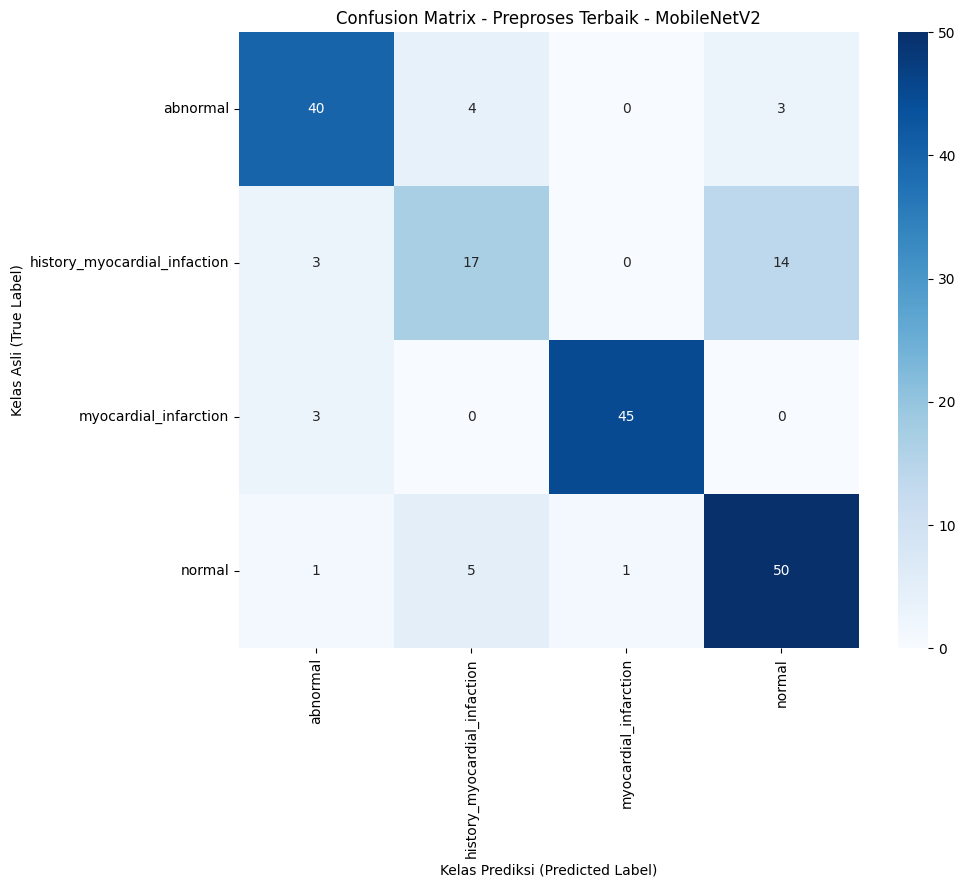


Plot confusion matrix telah disimpan sebagai: 'result/run-1/confusion_matrix_resnet50_terbaik.jpg'


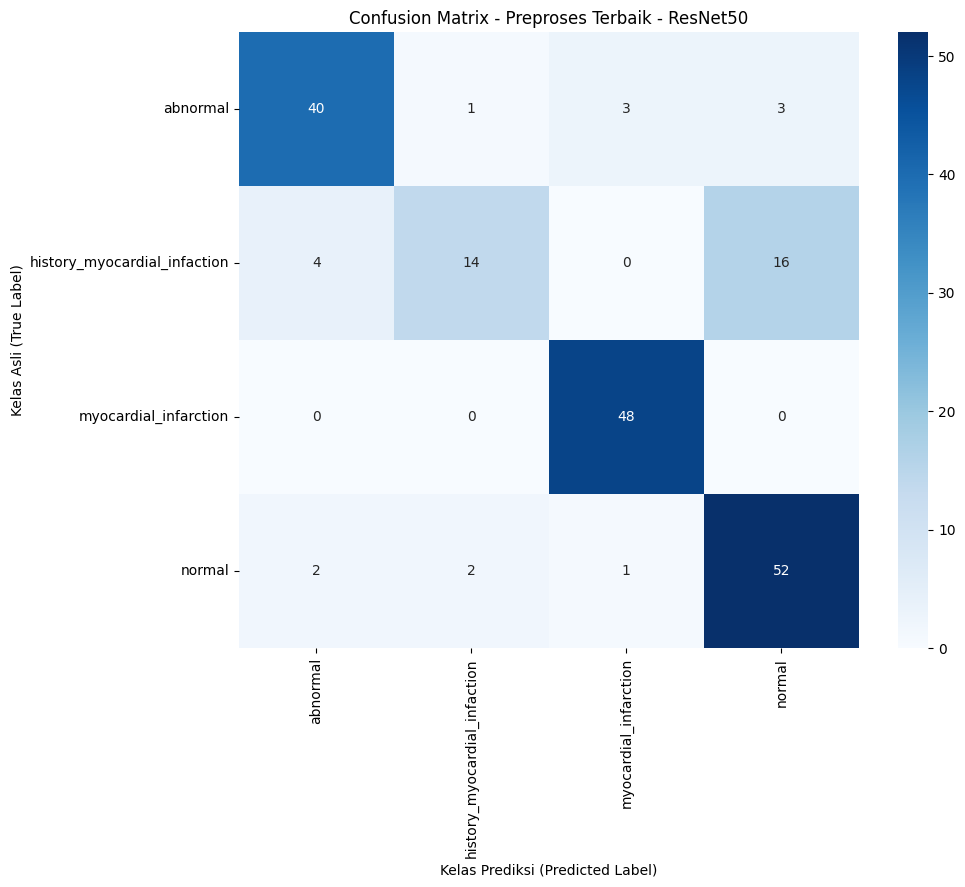


Plot confusion matrix telah disimpan sebagai: 'result/run-1/confusion_matrix_inceptionv3_terbaik.jpg'


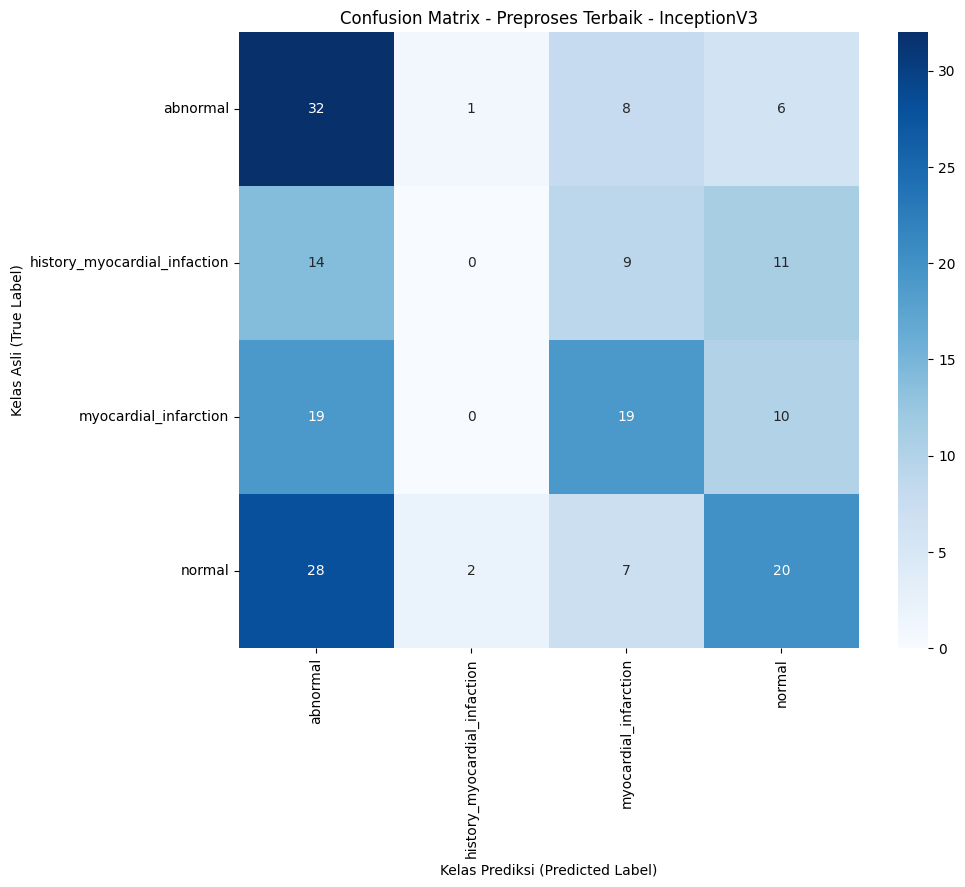


Laporan Klasifikasi (Classification Report):
                              precision    recall  f1-score   support

                    abnormal     0.8511    0.8511    0.8511        47
history_myocardial_infaction     0.6538    0.5000    0.5667        34
       myocardial_infarction     0.9783    0.9375    0.9574        48
                      normal     0.7463    0.8772    0.8065        57

                    accuracy                         0.8172       186
                   macro avg     0.8074    0.7914    0.7954       186
                weighted avg     0.8157    0.8172    0.8129       186


✅ Laporan juga telah disimpan ke file: 'result/run-1/classification_report_MobileNetV2_terbaik.txt'

Laporan Klasifikasi (Classification Report):
                              precision    recall  f1-score   support

                    abnormal     0.8696    0.8511    0.8602        47
history_myocardial_infaction     0.8235    0.4118    0.5490        34
       myocardial_infarction     

/tmp/ipykernel_19/604938147.py:25: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = Base_Model_Class(


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_branch_1            │ (None, 144, 224, 12)   │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_branch_2            │ (None, 141, 898, 1)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ adapter_branch_1 (Conv2D) │ (None, 144, 224, 3)    │             39 │ input_branch_1[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ adapter_branch_2 (Conv2D) │ (None, 141, 898, 3)    │              6 │ input_branch_2[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ base_model_branch_1       │ (None, 5, 7, 1280)     │      2,257,984 │ adapter_branch_1[0][0] │
│ (Functional)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ base_model_branch_2       │ (None, 5, 29, 1280)    │      2,257,984 │ adapter_branch_2[0][0] │
│ (Functional)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ gap_branch_1              │ (None, 1280)           │              0 │ base_model_branch_1[0… │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ gap_branch_2              │ (None, 1280)           │              0 │ base_model_branch_2[0… │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_features      │ (None, 2560)           │              0 │ gap_branch_1[0][0],    │
│ (Concatenate)             │                        │                │ gap_branch_2[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_6 (Dense)           │ (None, 256)            │        655,616 │ concatenate_features[… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_3 (Dropout)       │ (None, 256)            │              0 │ dense_6[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_7 (Dense)           │ (None, 4)              │          1,028 │ dropout_3[0][0]        │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 5,172,657 (19.73 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_branch_1            │ (None, 144, 224, 12)   │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_branch_2            │ (None, 141, 898, 1)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ adapter_branch_1 (Conv2D) │ (None, 144, 224, 3)    │             39 │ input_branch_1[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ adapter_branch_2 (Conv2D) │ (None, 141, 898, 3)    │              6 │ input_branch_2[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ base_model_branch_1       │ (None, 3, 5, 2048)     │     21,802,784 │ adapter_branch_1[0][0] │
│ (Functional)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ base_model_branch_2       │ (None, 3, 26, 2048)    │     21,802,784 │ adapter_branch_2[0][0] │
│ (Functional)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ gap_branch_1              │ (None, 2048)           │              0 │ base_model_branch_1[0… │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ gap_branch_2              │ (None, 2048)           │              0 │ base_model_branch_2[0… │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_features      │ (None, 4096)           │              0 │ gap_branch_1[0][0],    │
│ (Concatenate)             │                        │                │ gap_branch_2[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_10 (Dense)          │ (None, 256)            │      1,048,832 │ concatenate_features[… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_5 (Dropout)       │ (None, 256)            │              0 │ dense_10[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_11 (Dense)          │ (None, 4)              │          1,028 │ dropout_5[0][0]        │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 44,655,473 (170.35 MB)

 Trainable params: 1,049,905 (4.01 MB)

 Non-trainable params: 43,605,568 (166.34 MB)


Memulai pelatihan model MobileNetV2...
Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.3278 - loss: 1.6039 - val_accuracy: 0.5000 - val_loss: 1.2408
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 215ms/step - accuracy: 0.3924 - loss: 1.4369 - val_accuracy: 0.5753 - val_loss: 1.1113
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 219ms/step - accuracy: 0.4823 - loss: 1.2357 - val_accuracy: 0.6075 - val_loss: 1.0464
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 218ms/step - accuracy: 0.5111 - loss: 1.1470 - val_accuracy: 0.6667 - val_loss: 0.9749
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 217ms/step - accuracy: 0.5838 - loss: 1.0515 - val_accuracy: 0.7043 - val_loss: 0.9424
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 216ms/step - accuracy: 0.6221 - loss: 0.9633 - val_accuracy: 0.7097 - val_loss: 0.9120
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 214ms/step - accuracy: 0.6401 - loss: 0.9210 - val_accuracy: 0.7151 - val_loss: 0.8838
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 209ms/step - accuracy: 0.

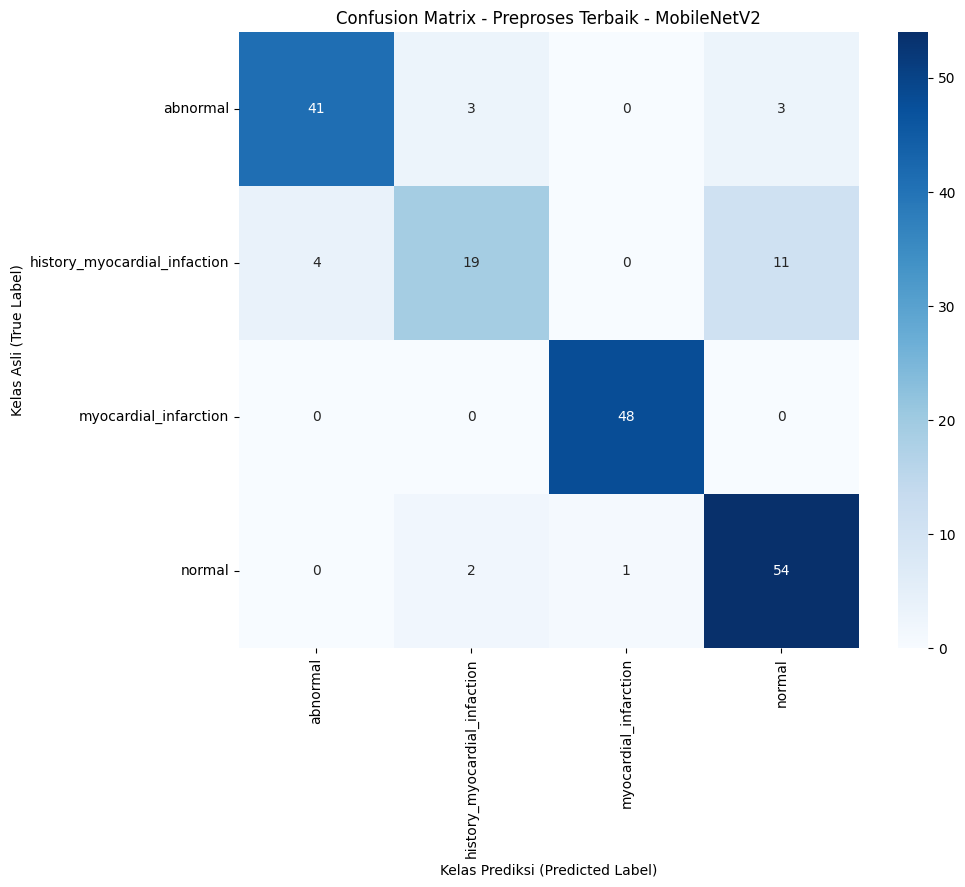


Plot confusion matrix telah disimpan sebagai: 'result/run-2/confusion_matrix_resnet50_terbaik.jpg'


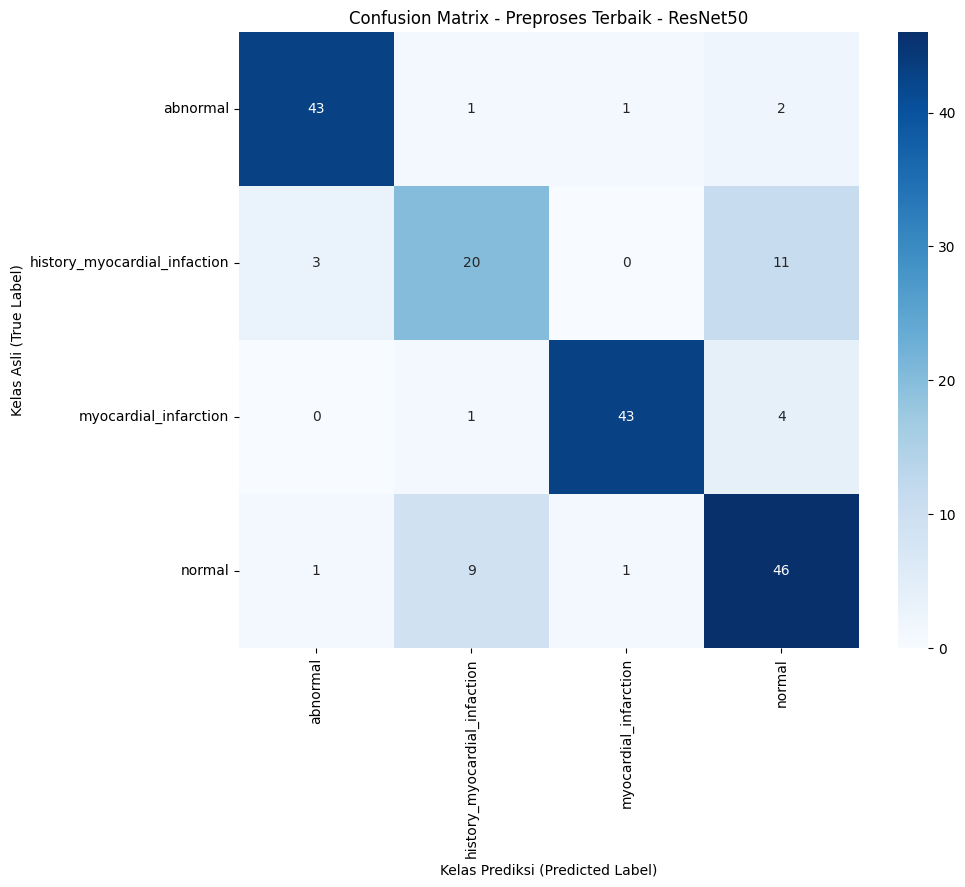


Plot confusion matrix telah disimpan sebagai: 'result/run-2/confusion_matrix_inceptionv3_terbaik.jpg'


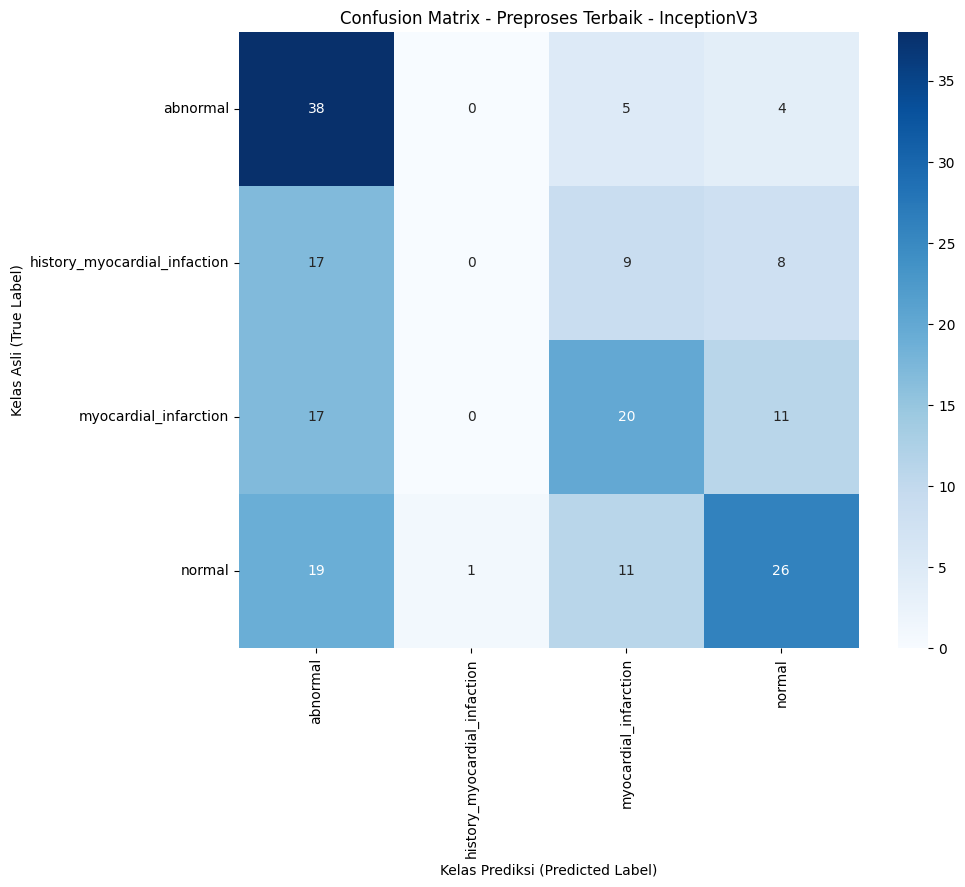


Laporan Klasifikasi (Classification Report):
                              precision    recall  f1-score   support

                    abnormal     0.9111    0.8723    0.8913        47
history_myocardial_infaction     0.7917    0.5588    0.6552        34
       myocardial_infarction     0.9796    1.0000    0.9897        48
                      normal     0.7941    0.9474    0.8640        57

                    accuracy                         0.8710       186
                   macro avg     0.8691    0.8446    0.8500       186
                weighted avg     0.8711    0.8710    0.8652       186


✅ Laporan juga telah disimpan ke file: 'result/run-2/classification_report_MobileNetV2_terbaik.txt'

Laporan Klasifikasi (Classification Report):
                              precision    recall  f1-score   support

                    abnormal     0.9149    0.9149    0.9149        47
history_myocardial_infaction     0.6452    0.5882    0.6154        34
       myocardial_infarction     

/tmp/ipykernel_19/604938147.py:25: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = Base_Model_Class(


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_branch_1            │ (None, 144, 224, 12)   │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_branch_2            │ (None, 141, 898, 1)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ adapter_branch_1 (Conv2D) │ (None, 144, 224, 3)    │             39 │ input_branch_1[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ adapter_branch_2 (Conv2D) │ (None, 141, 898, 3)    │              6 │ input_branch_2[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ base_model_branch_1       │ (None, 5, 7, 1280)     │      2,257,984 │ adapter_branch_1[0][0] │
│ (Functional)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ base_model_branch_2       │ (None, 5, 29, 1280)    │      2,257,984 │ adapter_branch_2[0][0] │
│ (Functional)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ gap_branch_1              │ (None, 1280)           │              0 │ base_model_branch_1[0… │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ gap_branch_2              │ (None, 1280)           │              0 │ base_model_branch_2[0… │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_features      │ (None, 2560)           │              0 │ gap_branch_1[0][0],    │
│ (Concatenate)             │                        │                │ gap_branch_2[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_12 (Dense)          │ (None, 256)            │        655,616 │ concatenate_features[… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_6 (Dropout)       │ (None, 256)            │              0 │ dense_12[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_13 (Dense)          │ (None, 4)              │          1,028 │ dropout_6[0][0]        │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 5,172,657 (19.73 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_branch_1            │ (None, 144, 224, 12)   │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_branch_2            │ (None, 141, 898, 1)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ adapter_branch_1 (Conv2D) │ (None, 144, 224, 3)    │             39 │ input_branch_1[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ adapter_branch_2 (Conv2D) │ (None, 141, 898, 3)    │              6 │ input_branch_2[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ base_model_branch_1       │ (None, 3, 5, 2048)     │     21,802,784 │ adapter_branch_1[0][0] │
│ (Functional)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ base_model_branch_2       │ (None, 3, 26, 2048)    │     21,802,784 │ adapter_branch_2[0][0] │
│ (Functional)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ gap_branch_1              │ (None, 2048)           │              0 │ base_model_branch_1[0… │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ gap_branch_2              │ (None, 2048)           │              0 │ base_model_branch_2[0… │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_features      │ (None, 4096)           │              0 │ gap_branch_1[0][0],    │
│ (Concatenate)             │                        │                │ gap_branch_2[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_16 (Dense)          │ (None, 256)            │      1,048,832 │ concatenate_features[… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_8 (Dropout)       │ (None, 256)            │              0 │ dense_16[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_17 (Dense)          │ (None, 4)              │          1,028 │ dropout_8[0][0]        │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 44,655,473 (170.35 MB)

 Trainable params: 1,049,905 (4.01 MB)

 Non-trainable params: 43,605,568 (166.34 MB)


Memulai pelatihan model MobileNetV2...
Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.2475 - loss: 1.5568 - val_accuracy: 0.2527 - val_loss: 1.3817
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 218ms/step - accuracy: 0.2834 - loss: 1.4699 - val_accuracy: 0.3065 - val_loss: 1.3713
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 204ms/step - accuracy: 0.3060 - loss: 1.4254 - val_accuracy: 0.2581 - val_loss: 1.3975
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 207ms/step - accuracy: 0.2225 - loss: 1.4270 - val_accuracy: 0.3065 - val_loss: 1.3756
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 208ms/step - accuracy: 0.2638 - loss: 1.4215 - val_accuracy: 0.3065 - val_loss: 1.3751
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 206ms/step - accuracy: 0.2773 - loss: 1.3960 - val_accuracy: 0.3065 - val_loss: 1.3714
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 201ms/step - accuracy: 0.2809 - loss: 1.3910 - val_accuracy: 0.3065 - val_loss: 1.3728
Epoch 7: early stopping
Restoring model weights from the end of th

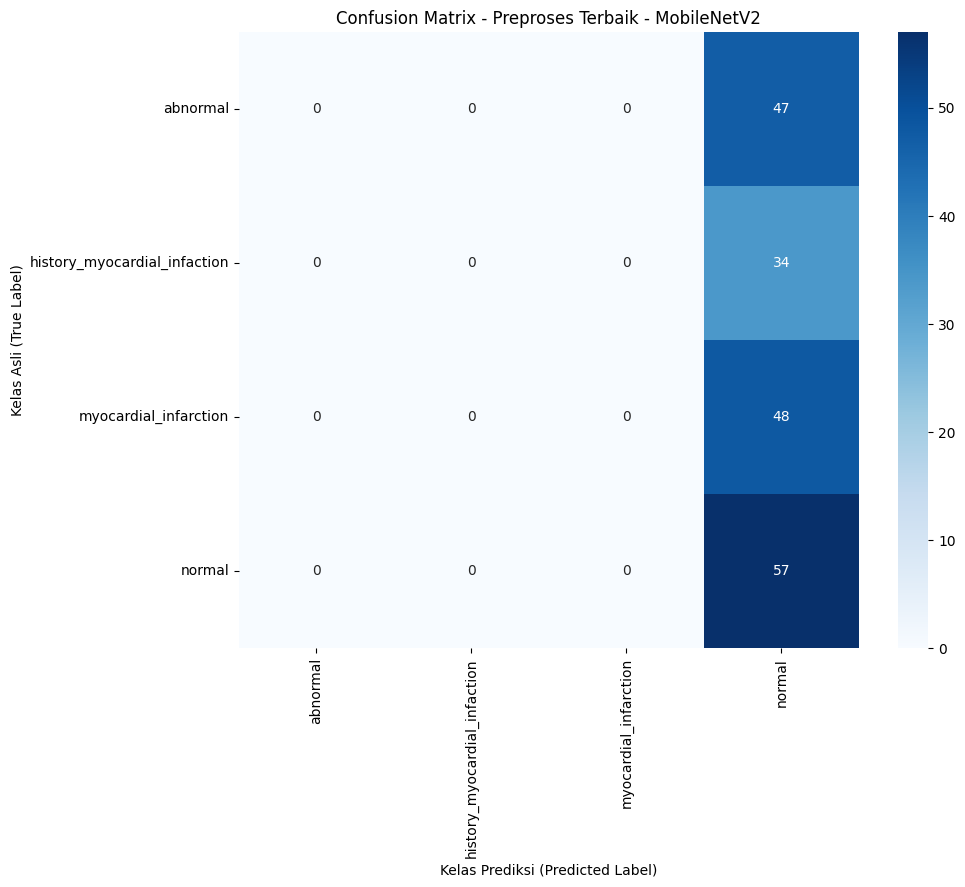


Plot confusion matrix telah disimpan sebagai: 'result/run-3/confusion_matrix_resnet50_terbaik.jpg'


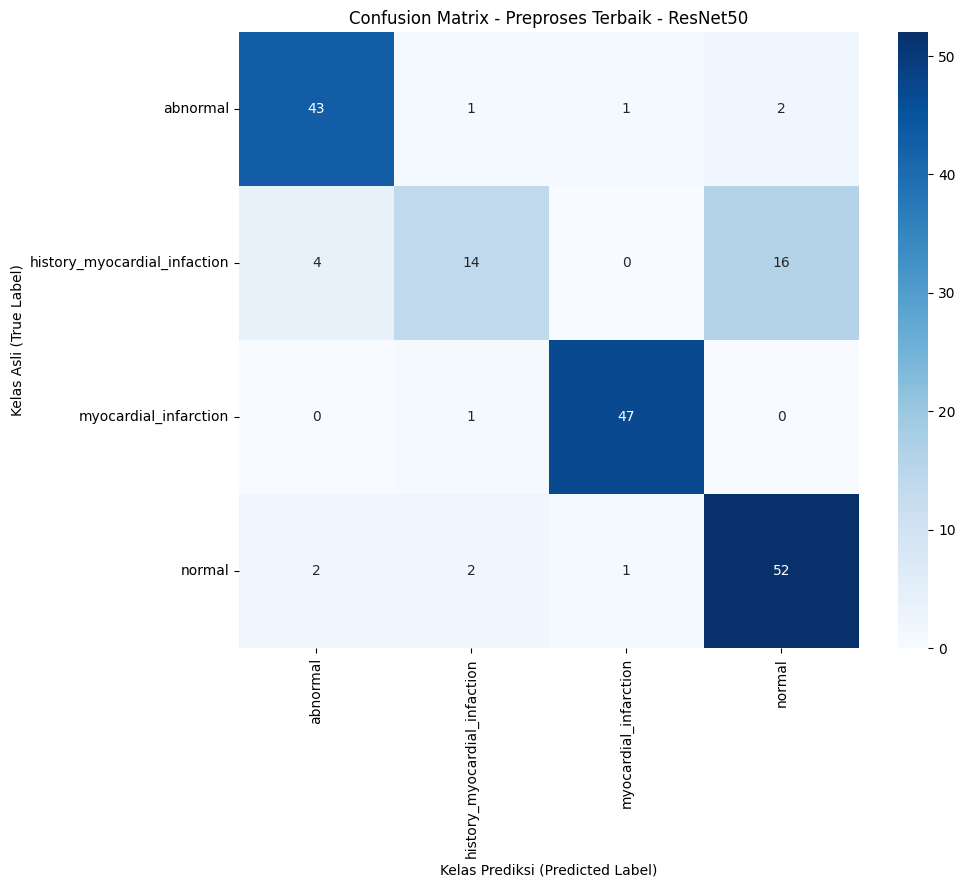


Plot confusion matrix telah disimpan sebagai: 'result/run-3/confusion_matrix_inceptionv3_terbaik.jpg'


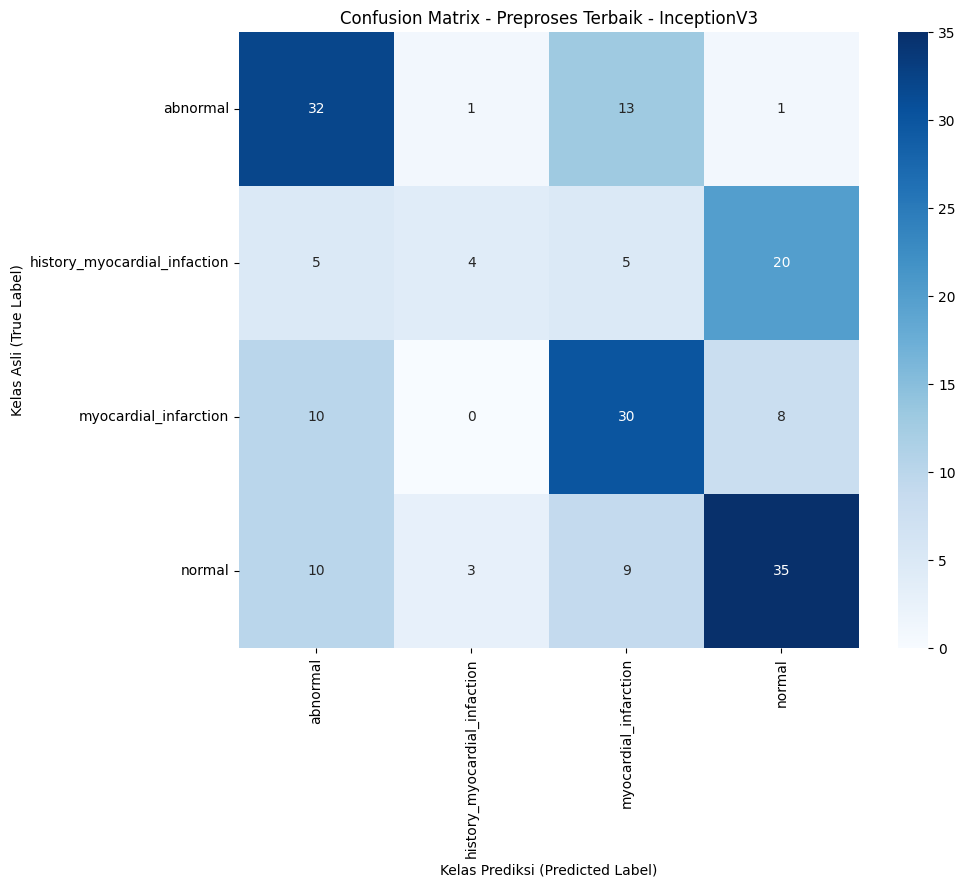


Laporan Klasifikasi (Classification Report):
                              precision    recall  f1-score   support

                    abnormal     0.0000    0.0000    0.0000        47
history_myocardial_infaction     0.0000    0.0000    0.0000        34
       myocardial_infarction     0.0000    0.0000    0.0000        48
                      normal     0.3065    1.0000    0.4691        57

                    accuracy                         0.3065       186
                   macro avg     0.0766    0.2500    0.1173       186
                weighted avg     0.0939    0.3065    0.1438       186


✅ Laporan juga telah disimpan ke file: 'result/run-3/classification_report_MobileNetV2_terbaik.txt'

Laporan Klasifikasi (Classification Report):
                              precision    recall  f1-score   support

                    abnormal     0.8776    0.9149    0.8958        47
history_myocardial_infaction     0.7778    0.4118    0.5385        34
       myocardial_infarction     

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [22]:
for tiap_run in folder_dibuat:
    model_names = ['MobileNetV2', 'ResNet50', 'InceptionV3']
    models = []
    data_tes_untuk_prediksi = X_test_reshaped

    for model_name in model_names:
        model = create_flexible_transfer_model(
            list_of_input_shapes=list_of_shapes,
            num_classes=NUM_CLASSES,
            model_name=model_name
        )
        model.summary()
        created_model = {"model": model, "model_name": model_name}
        models.append(created_model)
    
    for model in models:
        # --- KOMPILASI DAN LATIH MODEL ---
        model["model"].compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])
        
        early_stopping_callback = EarlyStopping(
            monitor="val_loss",
            patience=5,
            verbose=1,
            restore_best_weights=True
        );
        
        print(f"\nMemulai pelatihan model {model['model_name']}...")
        history = model["model"].fit(
            X_train_reshaped, # Langsung berikan list data Anda
            y_train,
            validation_data=(X_val_reshaped, y_val),
            epochs=50,
            batch_size=32,
            verbose=1,
            callbacks=[early_stopping_callback]
        )

        simpan_laporan_kinerja(
                history=history,
                model=model["model"], # Gunakan variabel model yang baru saja dilatih
                X_test=data_tes_untuk_prediksi, # Berikan data tes dalam bentuk list
                y_test=y_test, # Label tes
                nama_model=f'{model_name} ', # Beri nama yang jelas
                folder_tujuan=tiap_run
            )
    
    prediksi = []

    for model in models:
    
        # 2. Panggil fungsi prediksi yang sudah diadaptasi
        cm, y_pred_classes = lakukan_prediksi(
            model=model["model"],
            list_data_tes=data_tes_untuk_prediksi,
            label_tes=y_test
        )
    
        hasil_prediksi = {"cm": cm, "y_pred_classes": y_pred_classes, "model_name": model["model_name"]}
        prediksi.append(hasil_prediksi)
        
    
    for pred in prediksi:
        menampilkan_dan_menyimpan_confusion_matrix(pred['cm'], tiap_run, pred["model_name"])

    # Tentukan nama file laporan yang unik untuk setiap model
    for pred in prediksi:
        nama_file_laporan= os.path.join(tiap_run, f'classification_report_{pred["model_name"]}_terbaik.txt')
    
        # Panggil fungsi untuk menghasilkan dan menyimpan laporan
        laporan = generate_and_save_classification_report(
            y_true=y_test,
            y_pred=pred['y_pred_classes'],
            encoder=encoder,
            report_filename=nama_file_laporan
        )

    i += 1

In [23]:
!zip -r output.zip data_preprocess/

  adding: data_preprocess/ (stored 0%)
  adding: data_preprocess/04_clean/ (stored 0%)
  adding: data_preprocess/03_thres/ (stored 0%)
  adding: data_preprocess/05_lead/ (stored 0%)
  adding: data_preprocess/05_lead/02_short/ (stored 0%)
  adding: data_preprocess/05_lead/02_short/lead_aVR/ (stored 0%)
  adding: data_preprocess/05_lead/02_short/lead_V5/ (stored 0%)
  adding: data_preprocess/05_lead/02_short/lead_V1/ (stored 0%)
  adding: data_preprocess/05_lead/02_short/lead_V3/ (stored 0%)
  adding: data_preprocess/05_lead/02_short/lead_aVF/ (stored 0%)
  adding: data_preprocess/05_lead/02_short/lead_I/ (stored 0%)
  adding: data_preprocess/05_lead/02_short/lead_V4/ (stored 0%)
  adding: data_preprocess/05_lead/02_short/lead_V6/ (stored 0%)
  adding: data_preprocess/05_lead/02_short/lead_aVL/ (stored 0%)
  adding: data_preprocess/05_lead/02_short/lead_V2/ (stored 0%)
  adding: data_preprocess/05_lead/02_short/lead_III/ (stored 0%)
  adding: data_preprocess/05_lead/02_short/lead_II/ (st